# EDA du dataset CASIA
# Ce notebook charge les annotations et explore la distribution des labels et des types de modifications.


In [4]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


sns.set(style="whitegrid", font_scale=1.1)

# Chemin vers le dossier du dataset CASIA
root = Path("..") / "dataset" / "findit2"
csv_path = root / "train.txt"

# Lecture du fichier d’annotations
raw = pd.read_csv(csv_path)
raw.head()


,image,digital annotation,handwritten annotation,forged,forgery annotations
0,X00016469622.png,1,1,1,"{'filename': 'X00016469622.png', 'size': 23072..."
1,X00016469623.png,1,1,0,0
2,X00016469670.png,1,1,0,0
3,X00016469671.png,1,1,0,0
4,X00016469672.png,1,1,0,0


In [5]:
# Inspection rapide du dataset
print("Nombre total de lignes :", len(raw))
print(raw.dtypes)
print(raw.isna().sum())
print("\nValeurs uniques par colonne :")
print(raw.nunique())


Nombre total de lignes : 577
image                       str
digital annotation        int64
handwritten annotation    int64
forged                    int64
forgery annotations         str
dtype: object
image                     0
digital annotation        0
handwritten annotation    0
forged                    0
forgery annotations       0
dtype: int64

Valeurs uniques par colonne :
image                     577
digital annotation          2
handwritten annotation      2
forged                      2
forgery annotations        95
dtype: int64


In [6]:
def parse_annotation(value):
    if pd.isna(value):
        return None
    if value == 0 or value == "0":
        return None
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return None

raw["forgery_parsed"] = raw["forgery annotations"].apply(parse_annotation)
raw["has_annotation"] = raw["forgery_parsed"].apply(lambda x: isinstance(x, dict) and len(x.get("regions", [])) > 0)
raw["num_regions"] = raw["forgery_parsed"].apply(lambda x: len(x.get("regions", [])) if isinstance(x, dict) else 0)

raw[["image", "digital annotation", "handwritten annotation", "forged", "has_annotation", "num_regions"]].head()


,image,digital annotation,handwritten annotation,forged,has_annotation,num_regions
0,X00016469622.png,1,1,1,True,8
1,X00016469623.png,1,1,0,False,0
2,X00016469670.png,1,1,0,False,0
3,X00016469671.png,1,1,0,False,0
4,X00016469672.png,1,1,0,False,0


digital annotation         34
handwritten annotation    305
forged                     94
has_annotation             94
dtype: int64

Distribution des labels forged :
forged
0    483
1     94
Name: count, dtype: int64


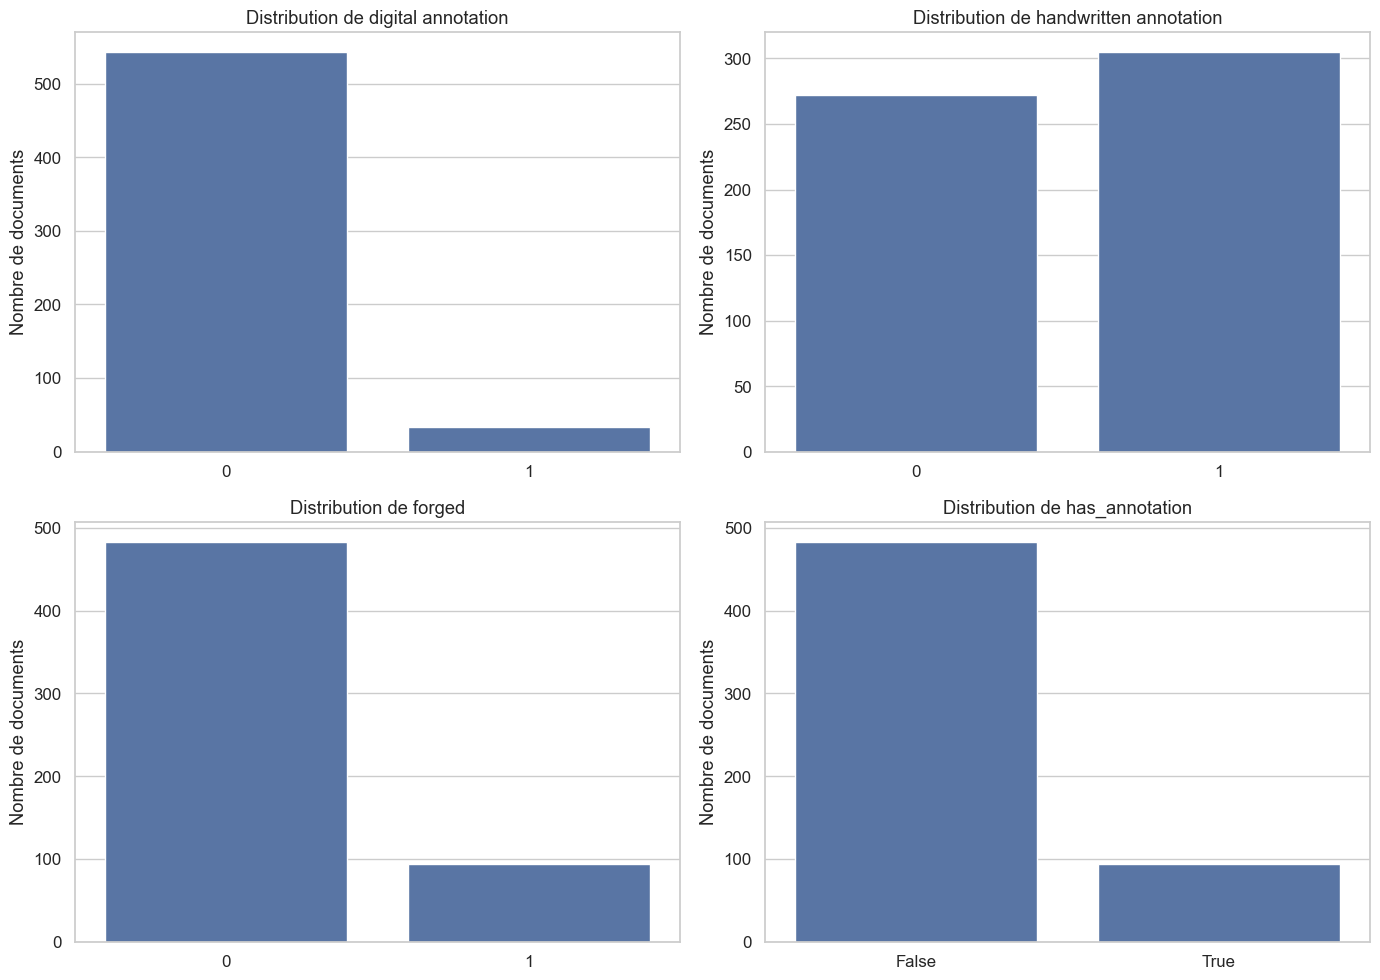

In [7]:
# Statistiques de base
counts = raw[["digital annotation", "handwritten annotation", "forged", "has_annotation"]].sum()
print(counts)
print("\nDistribution des labels forged :")
print(raw["forged"].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cols = ["digital annotation", "handwritten annotation", "forged", "has_annotation"]
for ax, col in zip(axes.flatten(), cols):
    sns.countplot(x=col, data=raw, ax=ax)
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Nombre de documents")
plt.tight_layout()
plt.show()


In [8]:
def extract_file_attributes(annotation):
    if isinstance(annotation, dict):
        return annotation.get("file_attributes", {})
    return {}

raw["file_attributes"] = raw["forgery_parsed"].apply(extract_file_attributes)
raw["software"] = raw["file_attributes"].apply(lambda x: x.get("Software used") if isinstance(x, dict) else None)

# Extraire le type d'entité et les types de modification depuis les régions
from collections import Counter

def flatten_regions(annotation):
    if not isinstance(annotation, dict):
        return []
    regions = annotation.get("regions", [])
    result = []
    for region in regions:
        attrs = region.get("region_attributes", {})
        if isinstance(attrs, dict):
            result.append(attrs)
    return result

raw["region_attributes"] = raw["forgery_parsed"].apply(flatten_regions)

entity_counter = Counter()
modified_area_counter = Counter()
original_area_counter = Counter()

for items in raw["region_attributes"]:
    for attrs in items:
        entity = attrs.get("Entity type")
        if entity:
            entity_counter[entity] += 1
        modified = attrs.get("Modified area")
        if isinstance(modified, dict):
            for key, value in modified.items():
                if value:
                    modified_area_counter[key] += 1
        elif modified:
            modified_area_counter[str(modified)] += 1
        original = attrs.get("Original area")
        if original:
            original_area_counter[original] += 1

print("Top logiciels utilisés pour les annotations :")
print(raw["software"].value_counts().head(10))

print("\nTop entités annotées :")
print(entity_counter.most_common(10))

print("\nTop types de modification :")
print(modified_area_counter.most_common(10))

print("\nTop valeurs pour Original area :")
print(original_area_counter.most_common(10))


Top logiciels utilisés pour les annotations :
software
gimp           40
paint          39
paint3d         7
aperçu          7
kolourpaint     1
Name: count, dtype: int64

Top entités annotées :
[('Total/payment', 188), ('Product', 84), ('Metadata', 69), ('Company', 20), ('Other', 17)]

Top types de modification :
[('CPI', 205), ('None', 103), ('CUT', 29), ('PIX', 27), ('IMI', 21), ('Autre', 7), ('CPO', 6)]

Top valeurs pour Original area :
[('no', 274), ('yes', 104)]
